# 3D shot map — Harry Kane (all games)

**6 shots** across **3 matches** in the five-match sample (not Hamburg only):

| Match | Shots |
|-------|-------|
| Bayern vs Hamburg | 1 |
| Frankfurt vs Bayern | 1 |
| Union vs Bayern | 4 |

Uses full multi-match tracking: `derived/shooting1_v3_all_matches/tracking_samples.csv`.

- **By match**: one panel per game (recommended)
- **Combined**: all 6 shots mirrored to one goal
- **By goal end**: left (2) | right (4)


In [1]:
from pathlib import Path

import pandas as pd
import plotly.io as pio

from aws_football.bsq_shot_trajectory_3d import (
    load_player_shot_trajectories,
    plot_3d_shot_map,
    plot_3d_shot_map_by_goal,
    plot_3d_shot_map_by_match,
    display_matplotlib_figure,
    display_shot_map_interactive,
    write_shot_map_html,
    resolve_tracking_samples_path,
)

PLAYER = "Harry Kane"
TEAM = "Bayern"
tracking_path = resolve_tracking_samples_path()
print("tracking:", tracking_path)


tracking: /Users/tayyabkhan/Downloads/aws/derived/shooting1_v3_all_matches/tracking_samples.csv


In [2]:
trajectories = load_player_shot_trajectories(
    PLAYER,
    team_name=TEAM,
    tracking_path=tracking_path,
)

shots = pd.read_csv("../reference_outputs/shots.csv")
kane = shots[shots["player_name"] == PLAYER][
    ["event_id", "match_folder", "shot_result", "x", "y", "xg", "shot_foot", "type_of_shot"]
].sort_values("match_folder")
display(kane)
print(f"{len(trajectories)} trajectories with tracking")

,event_id,match_folder,shot_result,x,y,xg,shot_foot,type_of_shot
20,18902400001163,Bayern_Hamburg,successfulShot,40.90,-4.76,0.1166,right,rightLeg
62,18905200000509,Frankfurt_Bayern,successfulShot,32.89,-7.88,0.0444,right,rightLeg
108,18909300000535,Union_Bayern,blockedShot,-41.53,-7.53,0.0925,left,leftLeg
112,18909300000710,Union_Bayern,blockedShot,-37.71,10.35,0.0689,right,rightLeg
125,18909300001561,Union_Bayern,successfulShot,45.55,1.31,0.3400,NaN,head
126,18909300001600,Union_Bayern,blockedShot,31.21,10.05,0.0278,right,rightLeg


6 trajectories with tracking


## By match — all 3 games


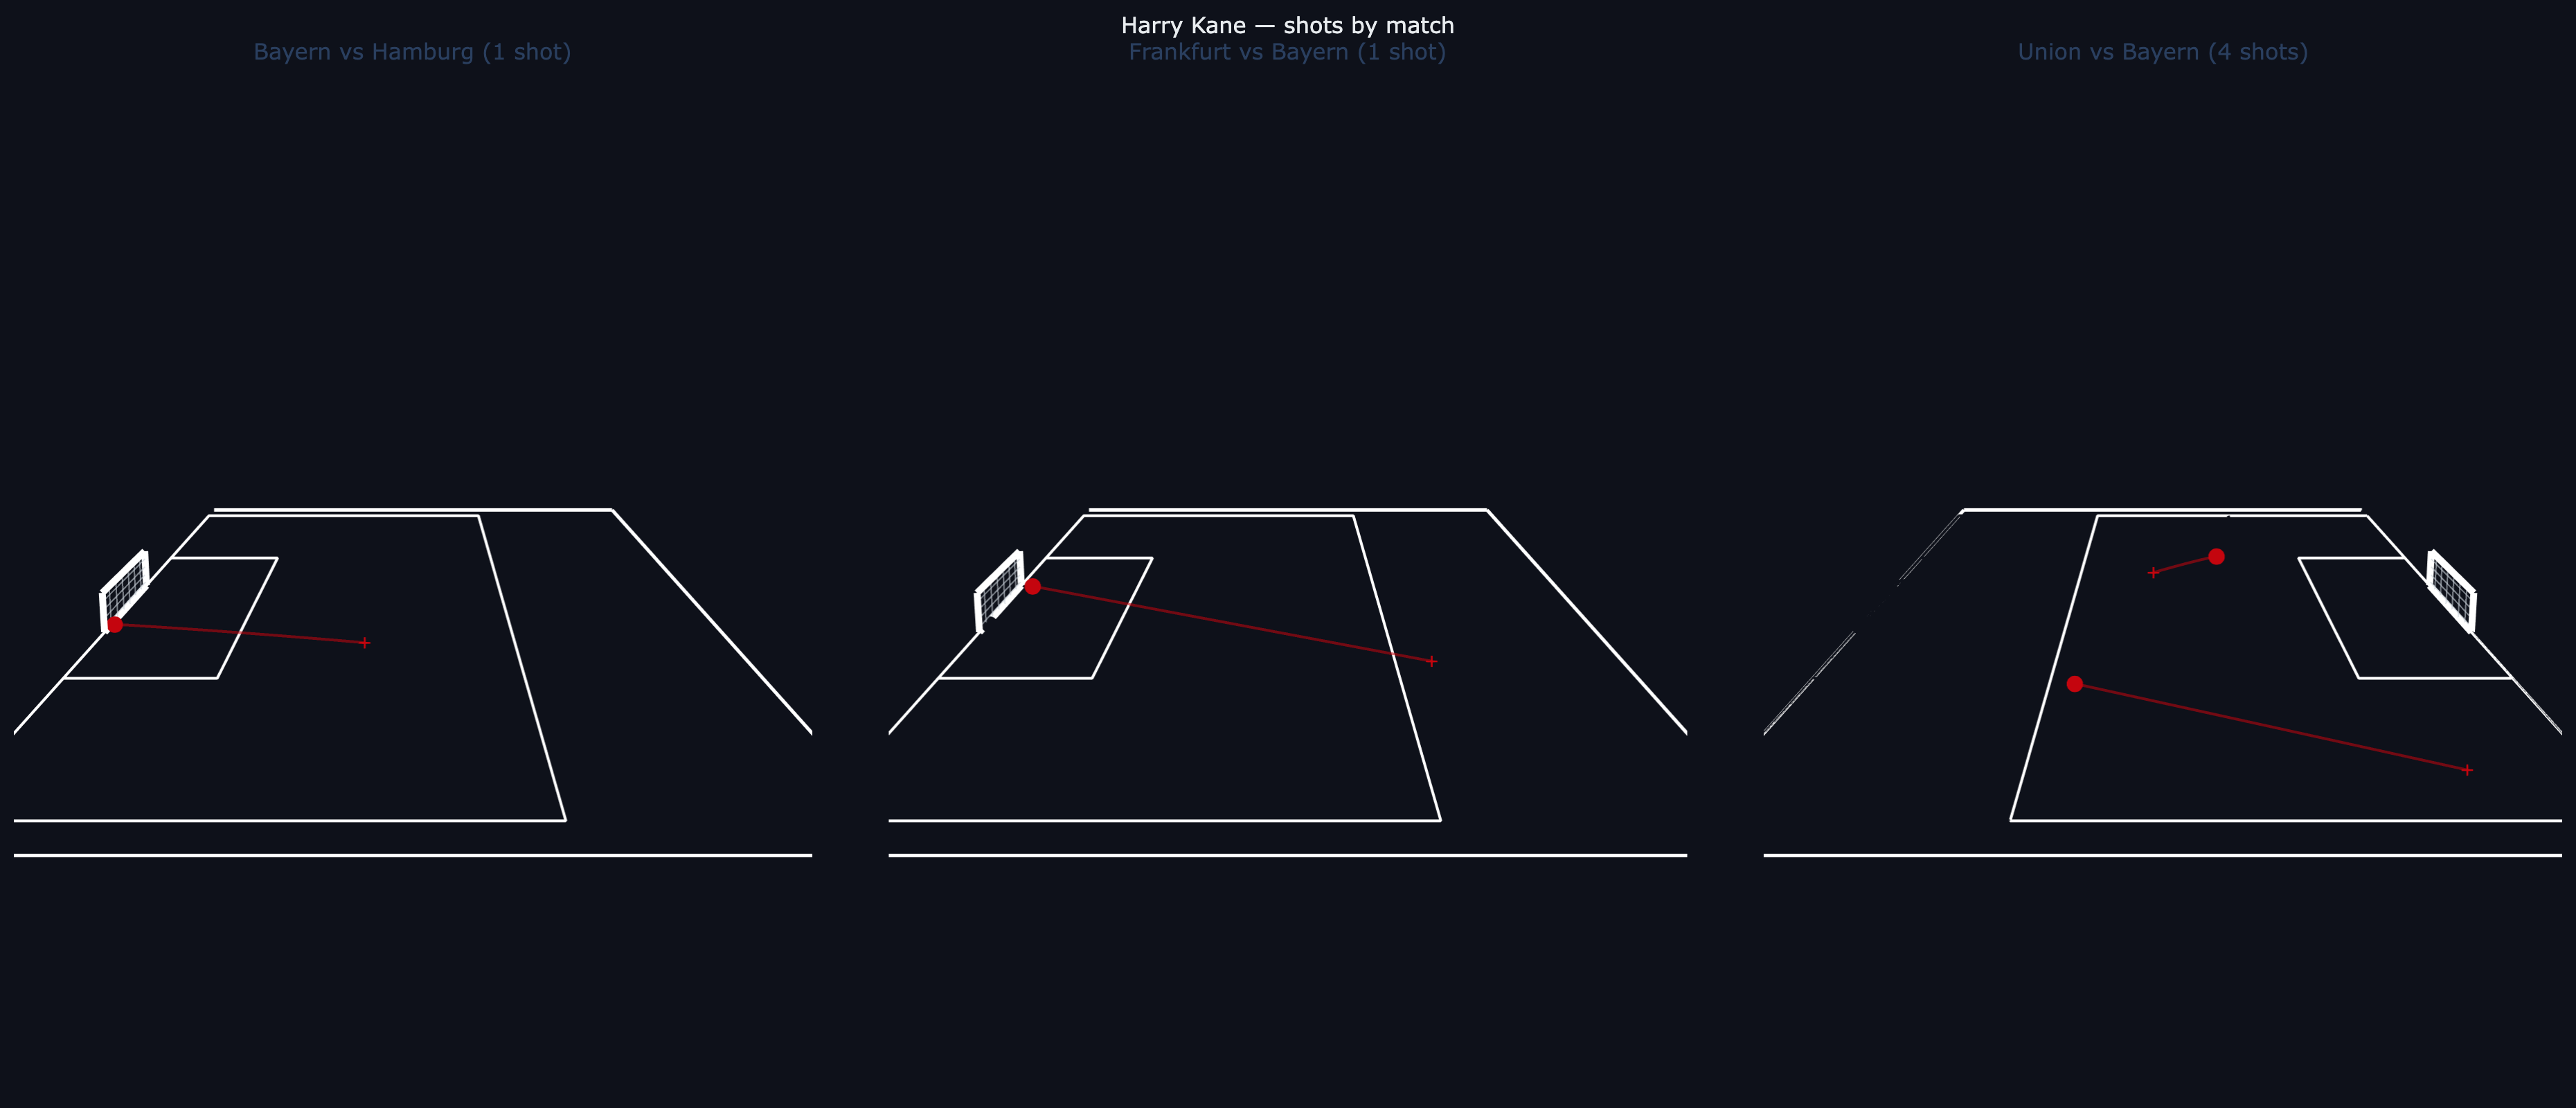

In [3]:
fig_matches = plot_3d_shot_map_by_match(
    trajectories,
    title=f"{PLAYER} — shots by match",
    highlight_event_id=18909300001561,
)
pio.write_image(
    fig_matches,
    Path("../../outputs/shot_map_harry_kane_by_match.png"),
    width=1860,
    height=800,
    scale=2,
)
display_matplotlib_figure(fig_matches, dpi=180)


## All 6 shots (mirrored to one goal)

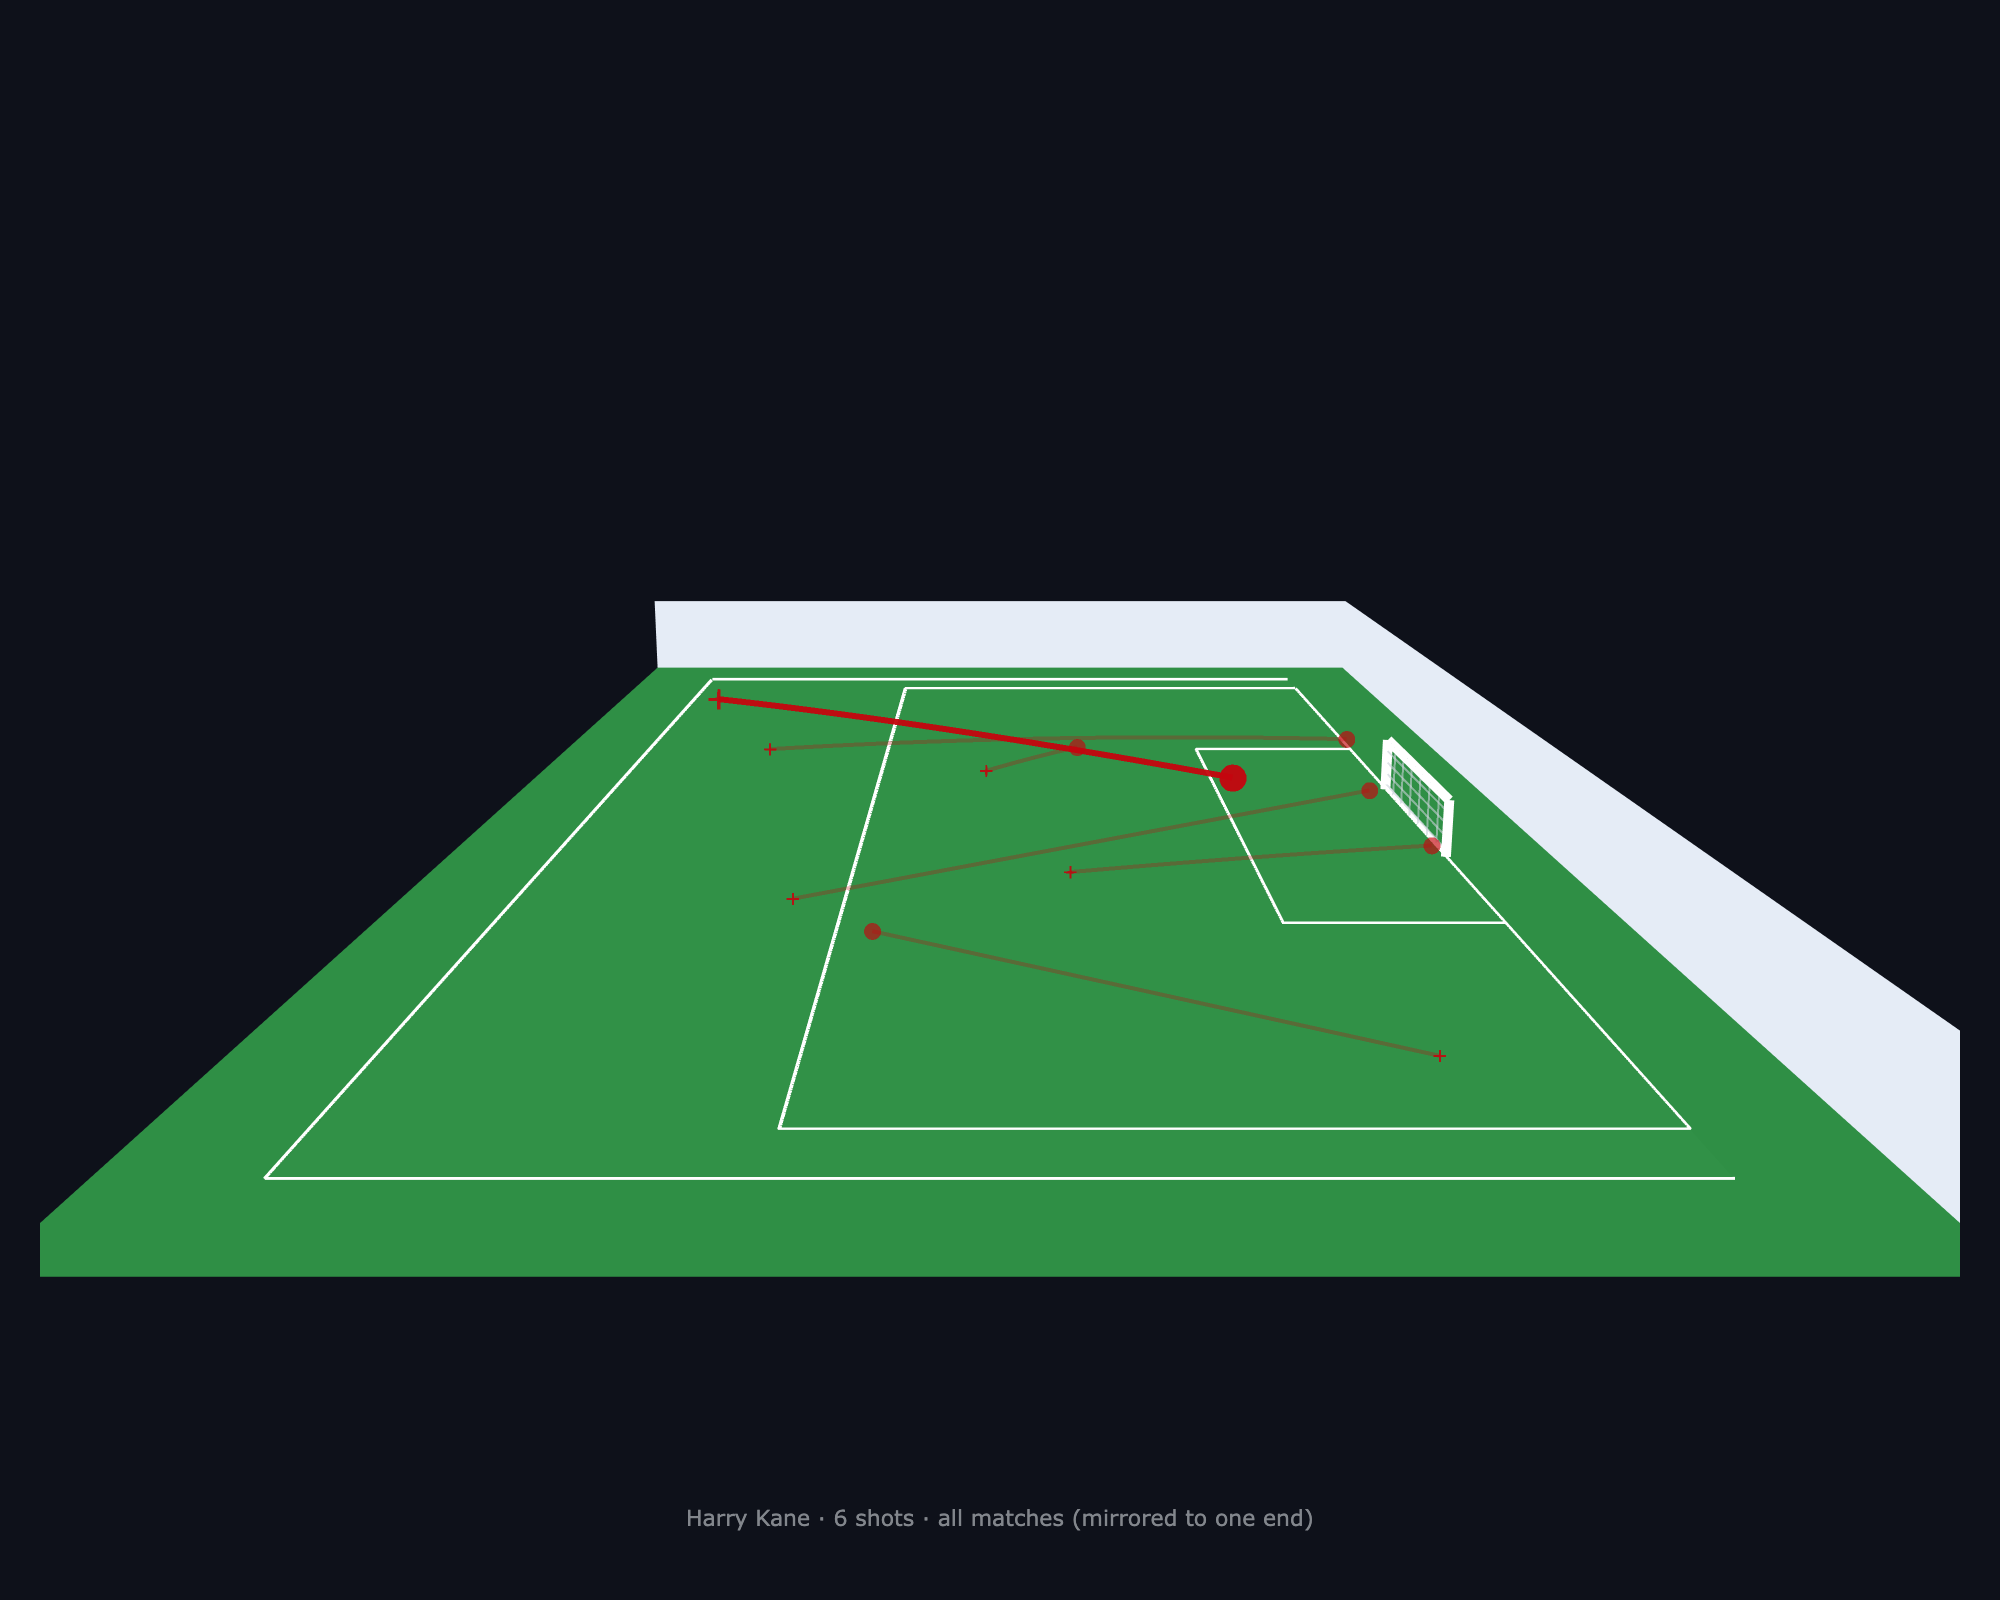

In [4]:
KANE_GOALS = [18902400001163, 18905200000509, 18909300001561]

fig_all = plot_3d_shot_map(
    trajectories,
    goal_filter="all",
    mirror_to_one_goal=True,
    subtitle=f"{PLAYER} · {len(trajectories)} shots · all matches (mirrored to one end)",
    highlight_event_id=18909300001561,
)
pio.write_image(
    fig_all,
    Path("../../outputs/shot_map_harry_kane_all.png"),
    width=1000,
    height=800,
    scale=2,
)
display_matplotlib_figure(fig_all, dpi=180)

## By goal end (true directions)

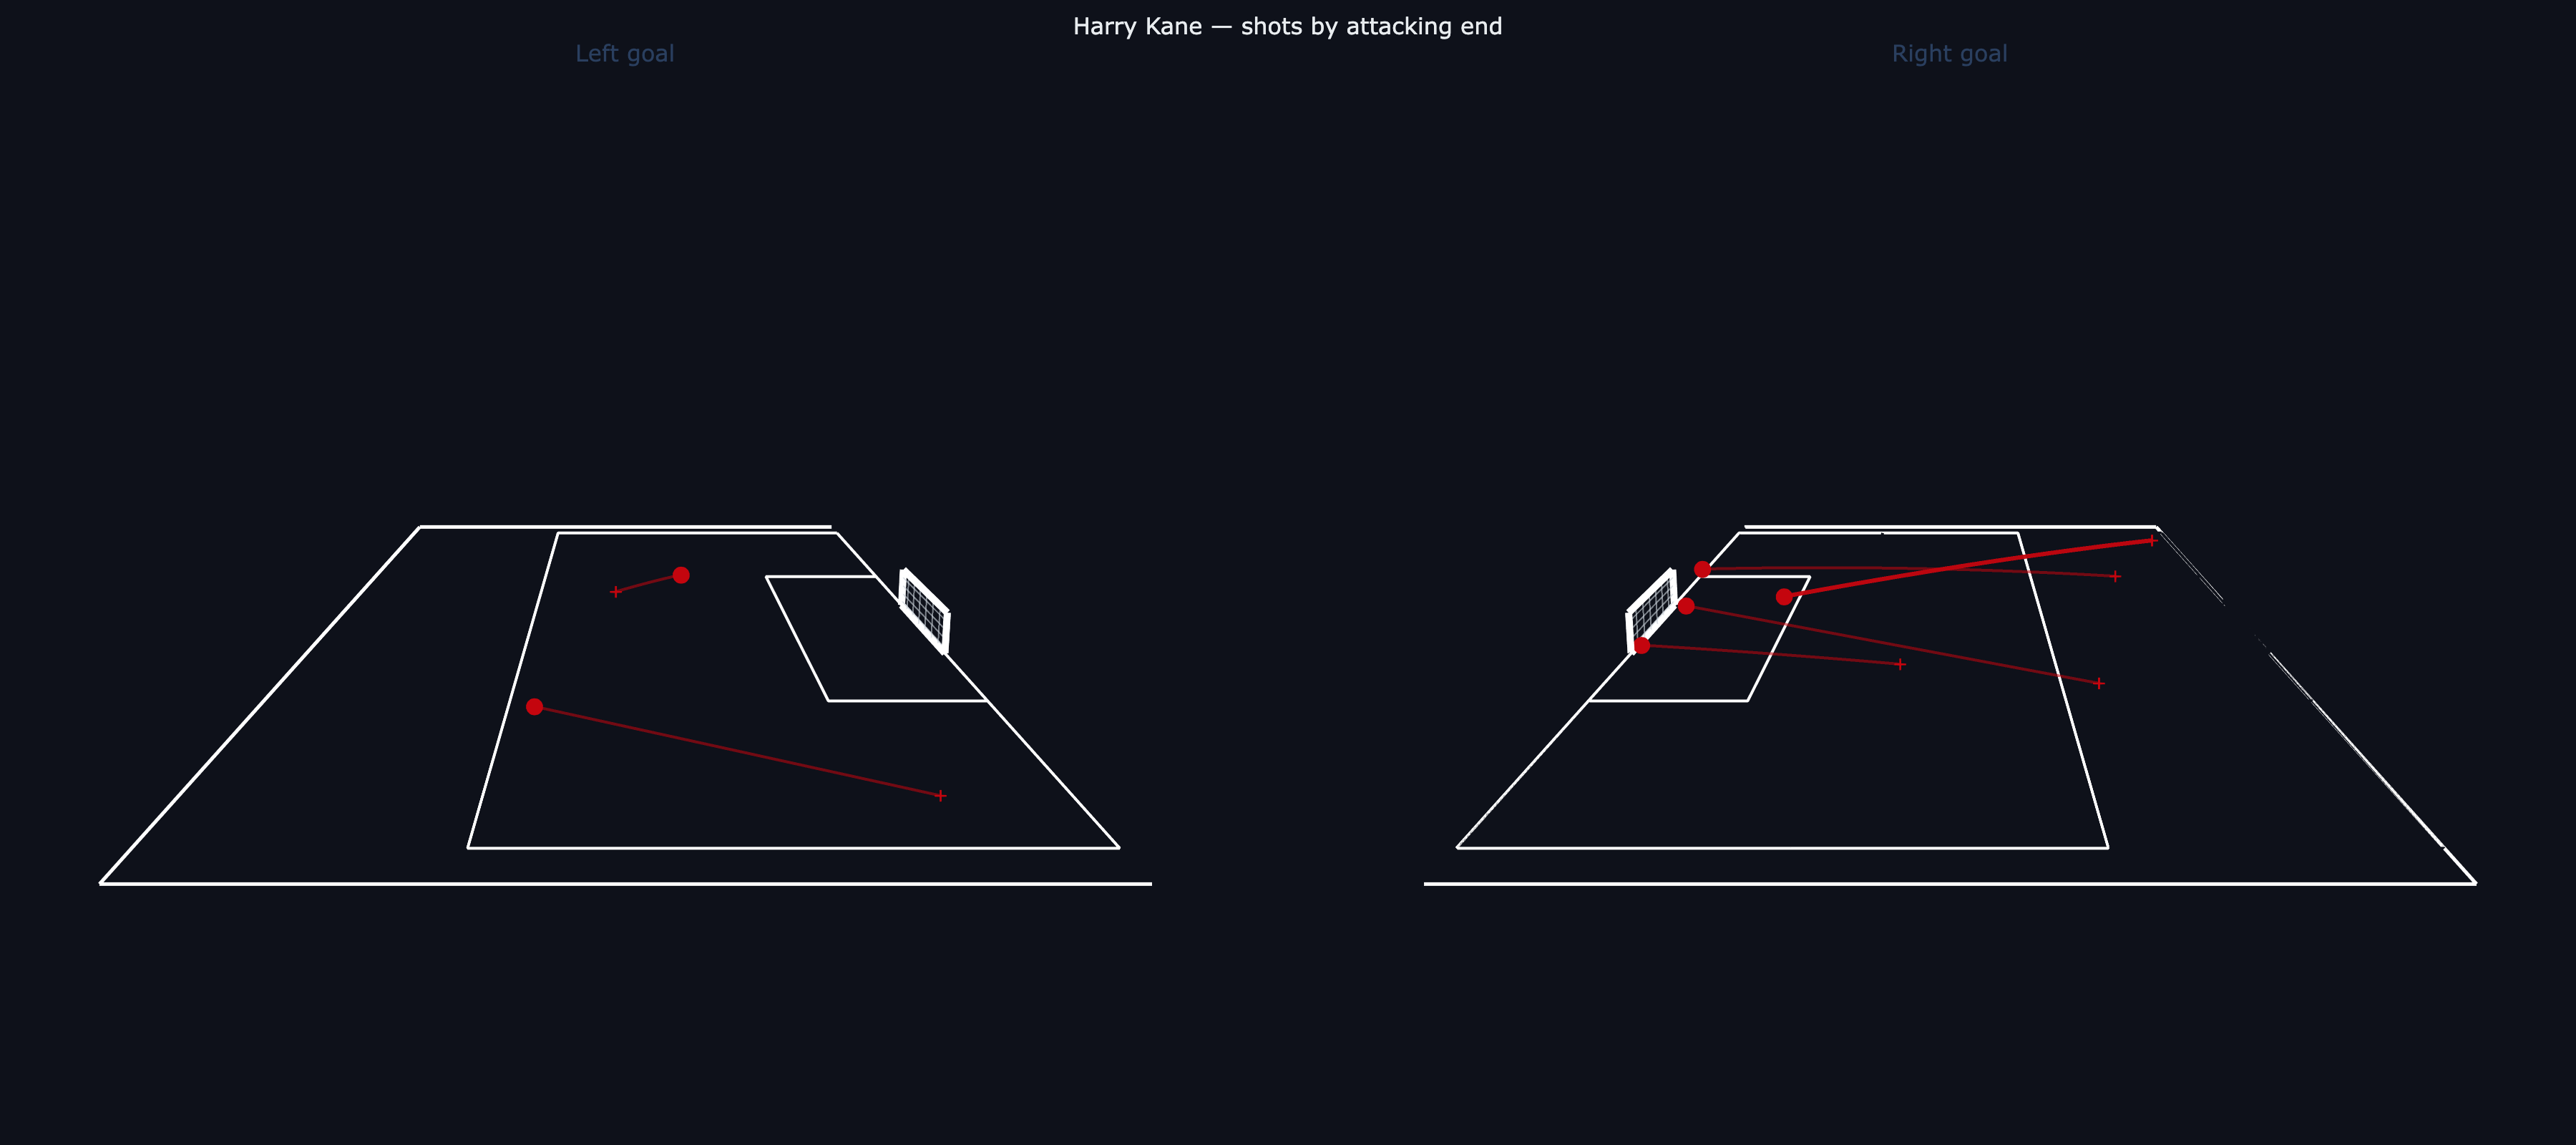

In [5]:
fig_ends = plot_3d_shot_map_by_goal(
    trajectories,
    title=f"{PLAYER} — shots by attacking end",
    highlight_event_id=18909300001561,
)
pio.write_image(
    fig_ends,
    Path("../../outputs/shot_map_harry_kane_by_goal.png"),
    width=1800,
    height=800,
    scale=2,
)
display_matplotlib_figure(fig_ends, dpi=180)

### Interactive (orbit / zoom)

All **6 shots** on **one goal** (mirrored). Red trajectories, green pitch.


In [6]:
html_path = Path("../../outputs/shot_map_harry_kane.html")
# Single goal: all 6 shots mirrored to one end (not per-match / per-goal panels)
saved = display_shot_map_interactive(fig_all, html_path=html_path, iframe_height=820)
print(f"Open: {saved}")


Open: /Users/tayyabkhan/Downloads/aws/final-repo/outputs/shot_map_harry_kane.html
